# Shift Nek Snapshot Coordinates

Read a Nek snapshot using `FLAME.datasets.SEMDataset`, shift all `x` coordinates by a constant, and write back in Nek format.

In [73]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from mpi4py import MPI

from FLAME.datasets import SEMDataset
from FLAME.io_fronts import Case, folder
from pysemtools.io.ppymech.neksuite import pynekwrite

In [74]:
# ---- User inputs ----
BASE_DIR = Path("data/nek")
PHI = 0.40
LAT_SIZE = "100"
TIME_STEP = 200
POST = True
H_TAG = "h400"
MULTIPLE_RUNS = False
N_RUN = 0

X_SHIFT = 50  # add this constant to all x points
OUTPUT_SUFFIX = "_xshift"

In [75]:
comm = MPI.COMM_WORLD

case = Case(
    base_dir=BASE_DIR,
    phi=PHI,
    lat_size=LAT_SIZE,
    time_step=TIME_STEP,
    post=POST,
    multiple_runs=MULTIPLE_RUNS,
    n_run=N_RUN,
    h_tag=H_TAG,
)

case_dir = folder(case)
file_name = "po_postPremix" if POST else "premix"

if comm.rank == 0:
    print(f"Case directory: {case_dir}")
    print(f"Input snapshot: {file_name}0.f{TIME_STEP:05d}")

Case directory: data/nek/phi0.40/h400x100_ref
Input snapshot: po_postPremix0.f00200


In [76]:
# Read snapshot using SEMDataset routines from FLAME/datasets.py
ds = SEMDataset(
    folder_name=str(case_dir),
    file_name=file_name,
    time_step=TIME_STEP,
    comm=comm,
)
ds.reload_timestep(TIME_STEP)

x_before_min = comm.allreduce(float(np.min(ds.msh.x)), op=MPI.MIN)
x_before_max = comm.allreduce(float(np.max(ds.msh.x)), op=MPI.MAX)

if comm.rank == 0:
    print(f"x range before shift: [{x_before_min:.8f}, {x_before_max:.8f}]")

2026-03-12 09:59:55,594  pynekread             INFO      Reading file: /media/alexandros/OS/Users/alexp/Documents/Bachelor Thesis/Code/data/nek/phi0.40/h400x100_ref/po_postPremix0.f00001
2026-03-12 09:59:56,016  Mesh                  INFO      Mesh object initialized from coordinates with type: float64 - Elapsed time: 0.334657469999911s
2026-03-12 09:59:56,018  pynekread             INFO      File successfully read - Elapsed time: 0.42397886200024004s
2026-03-12 09:59:56,019  Coef                  INFO      Initializing Coef object
2026-03-12 09:59:56,020  Coef                  INFO      Getting derivative matrices
2026-03-12 09:59:56,023  Coef                  INFO      Calculating the components of the jacobian
2026-03-12 09:59:56,633  Coef                  INFO      Calculating the jacobian determinant and inverse of the jacobian matrix
2026-03-12 09:59:56,697  Coef                  INFO      Calculating the mass matrix
2026-03-12 09:59:56,709  Coef                  INFO      Coef o

In [77]:
# Shift all x coordinates
ds.msh.x = ds.msh.x + float(X_SHIFT)

x_after_min = comm.allreduce(float(np.min(ds.msh.x)), op=MPI.MIN)
x_after_max = comm.allreduce(float(np.max(ds.msh.x)), op=MPI.MAX)

if comm.rank == 0:
    print(f"x range after shift : [{x_after_min:.8f}, {x_after_max:.8f}]")
    print(f"Applied shift      : {X_SHIFT:.8f}")

x range after shift : [50.00000000, 450.00000000]
Applied shift      : 50.00000000


In [78]:
# Write shifted data back in Nek format
output_name = f"{file_name}{OUTPUT_SUFFIX}0.f{TIME_STEP:05d}"
output_path = case_dir / output_name
output_path.parent.mkdir(parents=True, exist_ok=True)  


pynekwrite(
    str(output_path),
    comm,
    msh=ds.msh,
    fld=ds.fld,
    istep=TIME_STEP,
    write_mesh=True,
)

if comm.rank == 0:
    print(f"Wrote shifted Nek snapshot: {output_path}")

2026-03-12 09:59:58,747  pynekwrite            INFO      Writing file: data/nek/phi0.40/h400x100_ref/po_postPremix_xshift0.f00200
2026-03-12 09:59:59,775  pynekwrite            INFO      File written - Elapsed time: 1.0282318869999472s
Wrote shifted Nek snapshot: data/nek/phi0.40/h400x100_ref/po_postPremix_xshift0.f00200


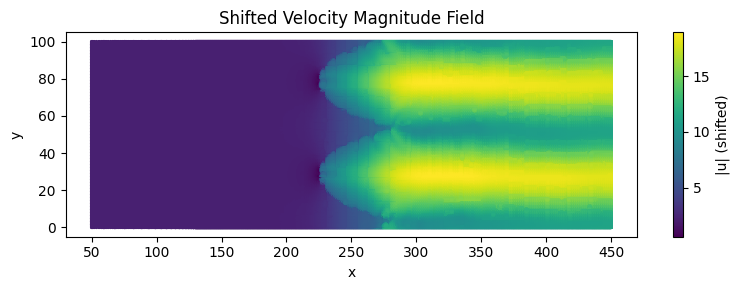

In [79]:
# Plot shifted velocity magnitude field (2D projection)
u_mag = np.sqrt(ds.u**2 + ds.v**2)

x_plot = ds.msh.x.reshape(-1)
y_plot = ds.msh.y.reshape(-1)
u_plot = u_mag.reshape(-1)

if comm.rank == 0:
    plt.figure(figsize=(8, 3))
    sc = plt.scatter(x_plot, y_plot, c=u_plot, s=2, cmap="viridis")
    plt.colorbar(sc, label="|u| (shifted)")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Shifted Velocity Magnitude Field")
    plt.tight_layout()
    plt.show()

In [80]:
# Import helper functions
import pysemtools.interpolation.utils as interp_utils

TARGET_GLL_POINTS_CSV = Path("target_gll_points_unique.csv")
DOMAIN_TOL = 1e-10

# Current (source) mesh domain bounds (global over MPI ranks)
src_x_min = comm.allreduce(float(np.min(ds.msh.x)), op=MPI.MIN)
src_x_max = comm.allreduce(float(np.max(ds.msh.x)), op=MPI.MAX)
src_y_min = comm.allreduce(float(np.min(ds.msh.y)), op=MPI.MIN)
src_y_max = comm.allreduce(float(np.max(ds.msh.y)), op=MPI.MAX)
src_z_min = comm.allreduce(float(np.min(ds.msh.z)), op=MPI.MIN)
src_z_max = comm.allreduce(float(np.max(ds.msh.z)), op=MPI.MAX)

if comm.Get_rank() == 0:
    # Read target GLL points and keep only points present in both domains
    # (target GLL domain and current source mesh domain)
    xyz_all = np.loadtxt(TARGET_GLL_POINTS_CSV, delimiter=",", skiprows=1)
    if xyz_all.ndim == 1:
        xyz_all = xyz_all.reshape(1, -1)

    in_source_domain = (
        (xyz_all[:, 0] >= src_x_min - DOMAIN_TOL) & (xyz_all[:, 0] <= src_x_max + DOMAIN_TOL) &
        (xyz_all[:, 1] >= src_y_min - DOMAIN_TOL) & (xyz_all[:, 1] <= src_y_max + DOMAIN_TOL) &
        (xyz_all[:, 2] >= src_z_min - DOMAIN_TOL) & (xyz_all[:, 2] <= src_z_max + DOMAIN_TOL)
    )
    xyz = xyz_all[in_source_domain]

    if xyz.size == 0:
        raise RuntimeError(
            "No common GLL points were found between target_gll_points and the current source domain."
        )

    np.savetxt("points_common_gll.csv", xyz, delimiter=",", fmt="%.16e")
    print(f"Loaded {xyz_all.shape[0]} target GLL points from {TARGET_GLL_POINTS_CSV}")
    print(f"Keeping {xyz.shape[0]} points inside source-domain bounds")
else:
    xyz = 1



In [ ]:

# Import helper function
from pysemtools.datatypes.utils import extrude_2d_sem_mesh

# Extrude the 2D mesh to 3D
msh3d, fld3d = extrude_2d_sem_mesh(comm, lz = ds.msh.lx, msh = ds.msh, fld = ds.fld)



2026-03-12 10:00:54,769  Mesh                  INFO      Mesh object initialized from coordinates with type: float64 - Elapsed time: 2.679190483000184s


In [ ]:
# Interpolate the interpolation module
from pysemtools.interpolation.probes import Probes

probes = Probes(comm, probes = xyz, msh = msh3d, point_interpolator_type='multiple_point_legendre_numpy', max_pts=256, find_points_comm_pattern='point_to_point')

2026-03-12 09:39:52,146  Probes                INFO      Initializing Probes object
2026-03-12 09:39:52,158  Probes                INFO      Query points (probes) read/assigned - Elapsed time: 0.00035715199987862434s
2026-03-12 09:39:54,082  Probes                INFO      Interpolator initialized in all ranks - Elapsed time: 1.9131364690001647s
2026-03-12 09:39:54,281  Interpolator          INFO      Elapsed time: 0.19650340799989863s
2026-03-12 09:39:54,283  Interpolator          INFO      Finding points - start
2026-03-12 09:39:57,976  Interpolator          INFO      Processing data in multiple ranks. Reporting progress only for rank 0
2026-03-12 09:39:57,977  Interpolator          INFO      Processing batch: 1 out of 1
2026-03-12 09:40:53,624  Probes                INFO      Finding points finalized in all ranks - Elapsed time: 59.341739496999935s
2026-03-12 09:40:53,640  Interpolator          INFO      Elapsed time: 0.015375520000134202s
2026-03-12 09:40:53,662  Probes            

In [ ]:
# Interpolate from a field list
probes.interpolate_from_field_list(0, [fld3d.registry['u']], comm, write_data=True)

2026-03-12 09:55:04,391  Probes                INFO      Interpolating fields from field list
2026-03-12 09:55:05,132  Probes                INFO      Finished interpolation and redistribution in all ranks - Aggregated time: 0.7370224139999664s
2026-03-12 09:55:05,133  Probes                INFO      Writing interpolated fields to ./interpolated_fields.csv
2026-03-12 09:55:06,355  Probes                INFO      Finished writing interpolated fields - Elapsed time: 1.222414702000151s


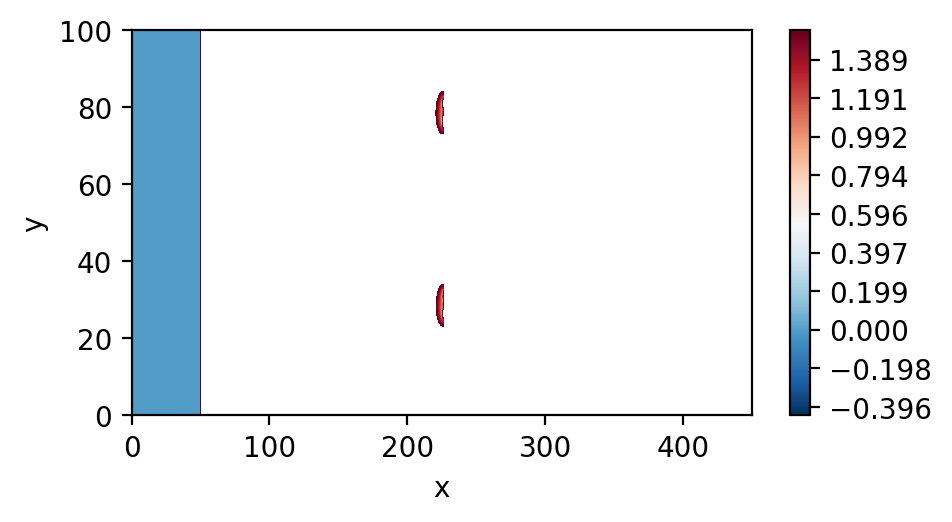

In [ ]:
if comm.Get_rank() == 0:
    # First column is time, first interpolated field is column 1
    u_int = probes.interpolated_fields[:, 1]

    levels = np.linspace(-0.44, 1.54, 500)
    cmapp = 'RdBu_r'
    fig, ax = plt.subplots(1, 1, figsize=(5, 2.5), dpi=200)

    c1 = ax.scatter(xyz[:, 0], xyz[:, 1], c=u_int, s=2, cmap=cmapp)
    fig.colorbar(c1)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    plt.show()



In [15]:
# ---- Write interpolated field to Nek .f* using a target template ----
from pysemtools.datatypes.msh import Mesh
from pysemtools.datatypes.field import FieldRegistry
from pysemtools.io.ppymech.neksuite import pynekread, pynekwrite

# Template Nek field file on the TARGET mesh (must exist)
TARGET_TEMPLATE_FPATH = Path("data/nek/target_template0.f00200")

# Output Nek file path
TARGET_OUTPUT_FPATH = Path("interpolated_on_target0.f00200")

# Which field in the target file to overwrite
TARGET_FIELD_KEY = "u"

# Coordinate matching tolerance used to map probe values to target GLL points
COORD_TOL = 1e-10

# If True, keep existing template values where no interpolated value exists
# If False, fill missing points with FILL_MISSING_VALUE
FILL_MISSING_FROM_TEMPLATE = True
FILL_MISSING_VALUE = 0.0



In [16]:
# Read target template file (mesh + field)
target_msh = Mesh(comm)
target_fld = FieldRegistry(comm)
pynekread(str(TARGET_TEMPLATE_FPATH), comm, msh=target_msh, fld=target_fld)

if TARGET_FIELD_KEY not in target_fld.registry:
    raise KeyError(f"Field '{TARGET_FIELD_KEY}' was not found in template file: {TARGET_TEMPLATE_FPATH}")

# Gather interpolated probe coordinates/values on all ranks
if comm.Get_rank() == 0:
    interp_xyz_root = xyz
    interp_vals_root = probes.interpolated_fields[:, 1]  # first interpolated field
else:
    interp_xyz_root = None
    interp_vals_root = None

interp_xyz = comm.bcast(interp_xyz_root, root=0)
interp_vals = comm.bcast(interp_vals_root, root=0)

# Build coordinate -> value lookup
scale = 1.0 / COORD_TOL
q_interp = np.rint(interp_xyz * scale).astype(np.int64)
value_map = {(int(a), int(b), int(c)): float(v) for (a, b, c), v in zip(q_interp, interp_vals)}

# Map onto local target mesh coordinates
out_field = target_fld.registry[TARGET_FIELD_KEY]
out_flat = out_field.reshape(-1)

if not FILL_MISSING_FROM_TEMPLATE:
    out_flat[:] = FILL_MISSING_VALUE

qx = np.rint(target_msh.x.reshape(-1) * scale).astype(np.int64)
qy = np.rint(target_msh.y.reshape(-1) * scale).astype(np.int64)
qz = np.rint(target_msh.z.reshape(-1) * scale).astype(np.int64)

assigned_local = 0
for i in range(out_flat.size):
    v = value_map.get((int(qx[i]), int(qy[i]), int(qz[i])))
    if v is not None:
        out_flat[i] = v
        assigned_local += 1

assigned_global = comm.allreduce(assigned_local, op=MPI.SUM)
total_global = comm.allreduce(out_flat.size, op=MPI.SUM)

if comm.Get_rank() == 0:
    print(f"Mapped interpolated values to {assigned_global}/{total_global} target DOFs")
    if assigned_global < total_global:
        if FILL_MISSING_FROM_TEMPLATE:
            print("Missing DOFs kept from template values")
        else:
            print(f"Missing DOFs filled with constant {FILL_MISSING_VALUE}")

# Write output in Nek format
pynekwrite(
    str(TARGET_OUTPUT_FPATH),
    comm,
    msh=target_msh,
    fld=target_fld,
    istep=TIME_STEP,
    write_mesh=True,
)

if comm.Get_rank() == 0:
    print(f"Wrote Nek file: {TARGET_OUTPUT_FPATH}")



2026-03-12 12:50:57,208  pynekread             INFO      Reading file: data/nek/target_template0.f00200


FileNotFoundError: [Errno 2] No such file or directory: 'data/nek/target_template0.f00200'